# Notebook 04b — Variables exógenas para SARIMAX

Se descargan datos meteorológicos horarios de PVGIS (ERA5, API v5.3)
para España (Madrid, 40.4°N, -3.7°E) para el periodo 2015-2023.

Se calcula el perfil climatológico medio hora a hora — promediando
todos los años disponibles para cada instante del año. Esto permite
disponer de exógenas para cualquier año futuro (2024, 2025) sin
necesidad de predicción ni de fuentes adicionales.

Variables finales:
- `ghi`: irradiancia global horizontal (W/m²)
- `solar_elevation`: elevación del sol (grados)
- `solar_azimuth`: posición del sol (grados) — calculada con pvlib

Resolución final: 15 minutos (interpolada desde horaria).
Salida: data_processed/exogenas_15min.parquet

In [1]:
import pandas as pd
import numpy as np
import requests
import pvlib
from pathlib import Path

LAT      = 40.4
LON      = -3.7
DATA_DIR = Path.cwd() / "data_processed"
PVGIS_URL = "https://re.jrc.ec.europa.eu/api/v5_3/seriescalc"

print(f"Coordenadas: {LAT}°N, {LON}°E")
print(f"pvlib: {pvlib.__version__}")

Coordenadas: 40.4°N, -3.7°E
pvlib: 0.15.0


## 1. Descarga de datos PVGIS ERA5 (2005-2023)

Se descargan datos horarios año a año para evitar timeouts.
Son 19 años × 8760 horas = ~166.000 observaciones horarias.

In [2]:
def descargar_pvgis(lat, lon, year):
    params = {
        "lat": lat,
        "lon": lon,
        "startyear": year,
        "endyear": year,
        "outputformat": "json",
        "raddatabase": "PVGIS-ERA5",
        "components": 0,
        "pvcalculation": 0,
        "usehorizon": 1,
    }
    print(f"Descargando {year}...")
    r = requests.get(PVGIS_URL, params=params, timeout=120)
    r.raise_for_status()
    
    hourly = r.json()["outputs"]["hourly"]
    df = pd.DataFrame(hourly)
    df["time"] = pd.to_datetime(df["time"], format="%Y%m%d:%H%M", utc=True)
    df = df.set_index("time")
    df = df.rename(columns={
        "G(i)":  "ghi",
        "H_sun": "solar_elevation"
    })
    df = df[["ghi", "solar_elevation"]].astype(float)
    print(f"  {year}: {len(df)} filas OK")
    return df

# Descargar 2005-2023
dfs = []
for year in range(2005, 2024):
    df_year = descargar_pvgis(LAT, LON, year)
    dfs.append(df_year)

df_pvgis = pd.concat(dfs).sort_index()
print(f"\nTotal descargado: {df_pvgis.shape}")
print(df_pvgis.head())

Descargando 2005...
  2005: 8760 filas OK
Descargando 2006...
  2006: 8760 filas OK
Descargando 2007...
  2007: 8760 filas OK
Descargando 2008...
  2008: 8784 filas OK
Descargando 2009...
  2009: 8760 filas OK
Descargando 2010...
  2010: 8760 filas OK
Descargando 2011...
  2011: 8760 filas OK
Descargando 2012...
  2012: 8784 filas OK
Descargando 2013...
  2013: 8760 filas OK
Descargando 2014...
  2014: 8760 filas OK
Descargando 2015...
  2015: 8760 filas OK
Descargando 2016...
  2016: 8784 filas OK
Descargando 2017...
  2017: 8760 filas OK
Descargando 2018...
  2018: 8760 filas OK
Descargando 2019...
  2019: 8760 filas OK
Descargando 2020...
  2020: 8784 filas OK
Descargando 2021...
  2021: 8760 filas OK
Descargando 2022...
  2022: 8760 filas OK
Descargando 2023...
  2023: 8760 filas OK

Total descargado: (166536, 2)
                           ghi  solar_elevation
time                                           
2005-01-01 00:30:00+00:00  0.0              0.0
2005-01-01 01:30:00+00:00  

## 2. Perfil climatológico medio

Se calcula la media histórica para cada (mes, día, hora) del año
promediando los 19 años disponibles. Esto genera un perfil típico
anual que se puede aplicar a cualquier año futuro.

In [3]:
# Añadir columnas de mes, día y hora para agrupar
df_pvgis["month"] = df_pvgis.index.month
df_pvgis["day"]   = df_pvgis.index.day
df_pvgis["hour"]  = df_pvgis.index.hour

# Media histórica por (mes, día, hora)
climatologia = (
    df_pvgis
    .groupby(["month", "day", "hour"])[["ghi", "solar_elevation"]]
    .mean()
    .reset_index()
)

print(f"Perfil climatológico: {climatologia.shape}")
print(climatologia.head(10))

Perfil climatológico: (8784, 5)
   month  day  hour         ghi  solar_elevation
0      1    1     0    0.000000             0.00
1      1    1     1    0.000000             0.00
2      1    1     2    0.000000             0.00
3      1    1     3    0.000000             0.00
4      1    1     4    0.000000             0.00
5      1    1     5    0.000000             0.00
6      1    1     6    0.000000             0.00
7      1    1     7    0.000000            -2.14
8      1    1     8   72.697368             7.35
9      1    1     9  179.584737            15.49


## 3. Construcción del índice temporal y azimut solar

Se construye un índice horario para 2022-2025 y se le asigna
el perfil climatológico. El azimut solar se calcula con pvlib
usando las coordenadas de Madrid.

In [4]:
# Construir índice horario 2022-2025
idx_horario = pd.date_range(
    start="2022-01-01 00:30:00",
    end="2025-12-31 23:30:00",
    freq="1h",
    tz="UTC"
)

df_exog = pd.DataFrame(index=idx_horario)
df_exog["month"] = df_exog.index.month
df_exog["day"]   = df_exog.index.day
df_exog["hour"]  = df_exog.index.hour

# Unir con perfil climatológico
df_exog = df_exog.merge(
    climatologia,
    on=["month", "day", "hour"],
    how="left"
).set_index(idx_horario)

# Calcular azimut solar con pvlib
location = pvlib.location.Location(
    latitude=LAT,
    longitude=LON,
    tz="UTC"
)
solpos = location.get_solarposition(idx_horario)
df_exog["solar_azimuth"] = solpos["azimuth"].values

df_exog = df_exog[["ghi", "solar_elevation", "solar_azimuth"]]

print(f"Exógenas horarias: {df_exog.shape}")
print(df_exog.head(10))

Exógenas horarias: (35064, 3)
                                  ghi  solar_elevation  solar_azimuth
2022-01-01 00:30:00+00:00    0.000000             0.00       9.100462
2022-01-01 01:30:00+00:00    0.000000             0.00      46.471509
2022-01-01 02:30:00+00:00    0.000000             0.00      67.952236
2022-01-01 03:30:00+00:00    0.000000             0.00      81.525569
2022-01-01 04:30:00+00:00    0.000000             0.00      91.839998
2022-01-01 05:30:00+00:00    0.000000             0.00     100.878540
2022-01-01 06:30:00+00:00    0.000000             0.00     109.644810
2022-01-01 07:30:00+00:00    0.000000            -2.14     118.788266
2022-01-01 08:30:00+00:00   72.697368             7.35     128.826770
2022-01-01 09:30:00+00:00  179.584737            15.49     140.197264


## 4. Interpolación a 15 minutos

Se interpola el perfil horario a resolución de 15 minutos para
alinear con la serie objetivo de huella de carbono.

In [6]:
# Construir índice limpio a 15min desde 00:00
idx_15min = pd.date_range(
    start="2022-01-01 00:00:00",
    end="2025-12-31 23:45:00",
    freq="15min",
    tz="UTC"
)

# Reindexar y interpolar para rellenar huecos
df_15min = df_exog.reindex(df_exog.index.union(idx_15min)).interpolate(method="time")
df_15min = df_15min.reindex(idx_15min)

# GHI no puede ser negativo
df_15min["ghi"] = df_15min["ghi"].clip(lower=0)

# Rellenar NaN iniciales con 0 para ghi y solar_elevation
# y forward fill para azimuth
df_15min["ghi"]             = df_15min["ghi"].fillna(0)
df_15min["solar_elevation"] = df_15min["solar_elevation"].fillna(0)
df_15min["solar_azimuth"]   = df_15min["solar_azimuth"].bfill()

print(f"NaN restantes: {df_15min.isna().sum().sum()}")

print(f"Exógenas 15min: {df_15min.shape}")
print(df_15min.head(8))

NaN restantes: 0
Exógenas 15min: (140256, 3)
                           ghi  solar_elevation  solar_azimuth
2022-01-01 00:00:00+00:00  0.0              0.0       9.100462
2022-01-01 00:15:00+00:00  0.0              0.0       9.100462
2022-01-01 00:30:00+00:00  0.0              0.0       9.100462
2022-01-01 00:45:00+00:00  0.0              0.0      18.443224
2022-01-01 01:00:00+00:00  0.0              0.0      27.785985
2022-01-01 01:15:00+00:00  0.0              0.0      37.128747
2022-01-01 01:30:00+00:00  0.0              0.0      46.471509
2022-01-01 01:45:00+00:00  0.0              0.0      51.841691


## 5. Verificación de alineación y guardado

Se verifica que el índice de las exógenas coincide exactamente
con el índice de la serie de huella de carbono.

In [7]:
# Cargar serie de huella para verificar alineación
y_train = pd.read_parquet(DATA_DIR / "train_2022_2023.parquet")["y"]
y_val   = pd.read_parquet(DATA_DIR / "val_2024.parquet")["y"]
y_test  = pd.read_parquet(DATA_DIR / "test_2025.parquet")["y"]

y_full  = pd.concat([y_train, y_val, y_test]).sort_index()
y_full.index = pd.to_datetime(y_full.index, utc=True)

# Verificar alineación
print(f"Serie huella:  {y_full.index.min()} → {y_full.index.max()} ({len(y_full)} obs)")
print(f"Exógenas:      {df_15min.index.min()} → {df_15min.index.max()} ({len(df_15min)} obs)")
print(f"Índices iguales: {y_full.index.equals(df_15min.index)}")

# Guardar
df_15min.to_parquet(DATA_DIR / "exogenas_15min.parquet")
print("\nGuardado en data_processed/exogenas_15min.parquet")

Serie huella:  2022-01-01 00:00:00+00:00 → 2025-12-31 23:45:00+00:00 (140256 obs)
Exógenas:      2022-01-01 00:00:00+00:00 → 2025-12-31 23:45:00+00:00 (140256 obs)
Índices iguales: True

Guardado en data_processed/exogenas_15min.parquet


## 6. Visualización del perfil climatológico

Se visualiza una semana de verano y una de invierno para verificar
que los perfiles de irradiancia y elevación solar son coherentes.

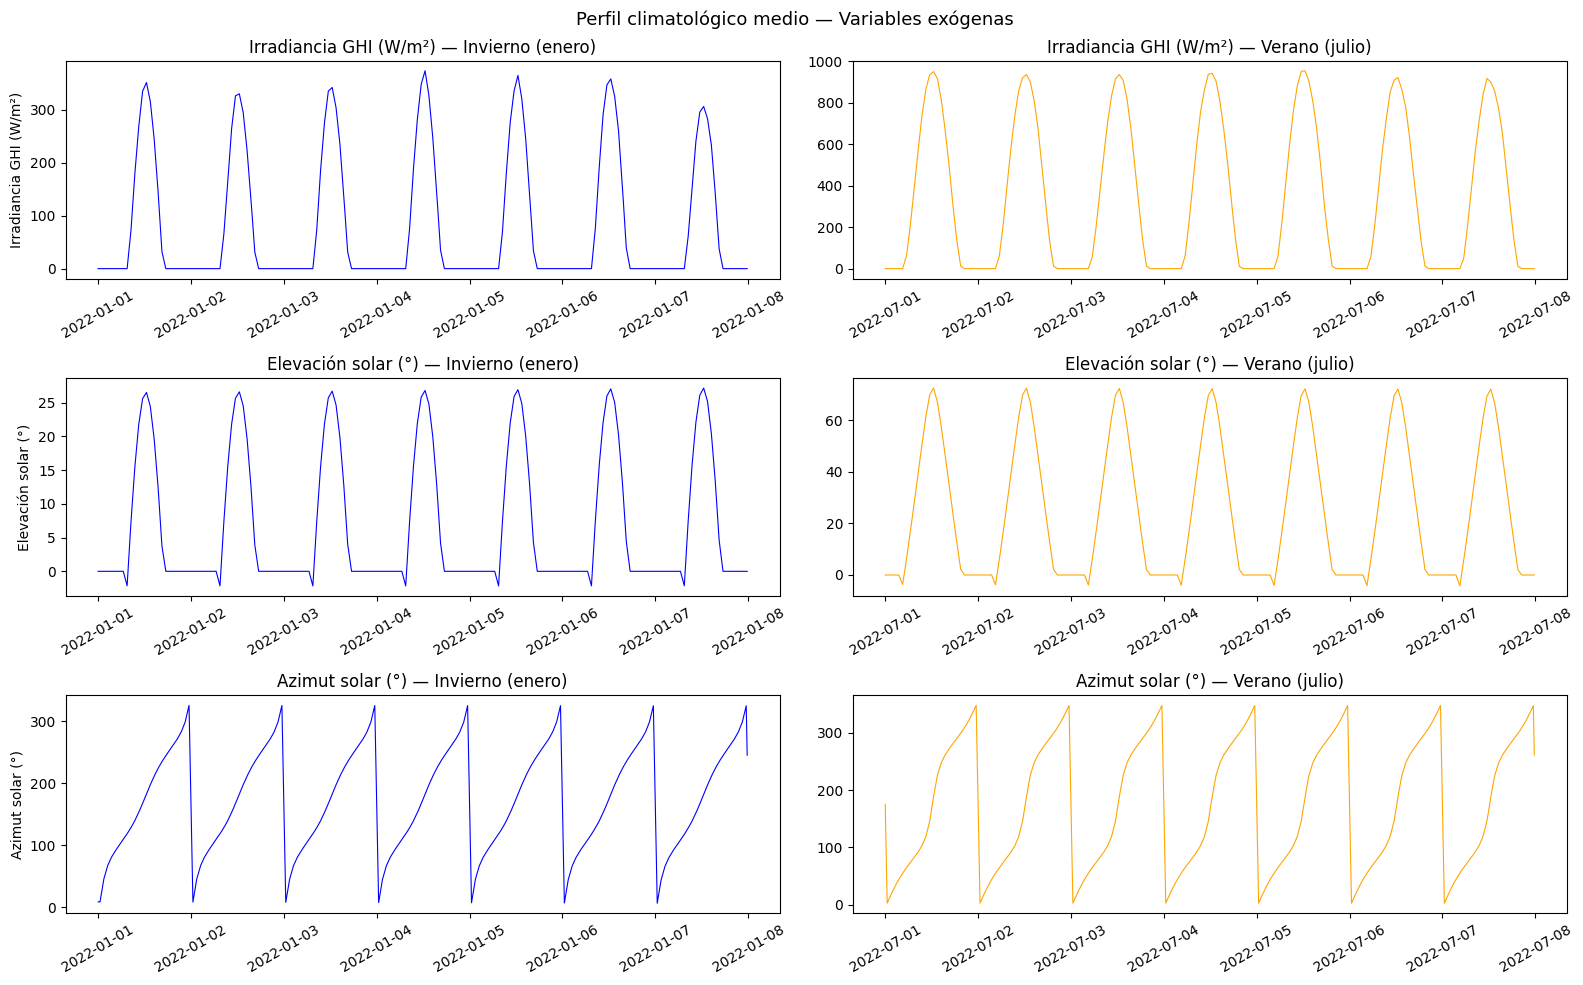

In [11]:
fig, axes = plt.subplots(3, 2, figsize=(16, 10))
fig.suptitle("Perfil climatológico medio — Variables exógenas", fontsize=13)

verano   = df_15min.loc["2022-07-01":"2022-07-07"]
invierno = df_15min.loc["2022-01-01":"2022-01-07"]

cols   = ["ghi", "solar_elevation", "solar_azimuth"]
labels = ["Irradiancia GHI (W/m²)", "Elevación solar (°)", "Azimut solar (°)"]

for i, (col, label) in enumerate(zip(cols, labels)):
    # Invierno
    axes[i][0].plot(invierno.index, invierno[col], color="blue", linewidth=0.8)
    axes[i][0].set_title(f"{label} — Invierno (enero)")
    axes[i][0].tick_params(axis="x", rotation=30)
    axes[i][0].set_ylabel(label)

    # Verano
    axes[i][1].plot(verano.index, verano[col], color="orange", linewidth=0.8)
    axes[i][1].set_title(f"{label} — Verano (julio)")
    axes[i][1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig("../figures/exogenas_perfil.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Resumen

Las variables exógenas están preparadas y alineadas con la serie
de huella de carbono. Guardadas en data_processed/exogenas_15min.parquet.

| Variable | Descripción | Unidad |
|---|---|---|
| ghi | Irradiancia global horizontal (perfil climatológico medio 2005-2023) | W/m² |
| solar_elevation | Elevación del sol sobre el horizonte | grados |
| solar_azimuth | Posición horizontal del sol | grados |

# Parte 2 — Modelo SARIMAX

Se extiende el SARIMA incorporando las variables exógenas meteorológicas
preparadas en la parte anterior.

Mismo orden que SARIMA: (2,1,0)(1,1,0,96)
Misma evaluación walk-forward: 12 fits distribuidos por 2024.

In [12]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from dataclasses import dataclass
from sklearn.metrics import mean_absolute_error, mean_squared_error

FREQ_MIN        = 15
STEPS_PER_HOUR  = 60 // FREQ_MIN
SEASONAL_PERIOD = 24 * STEPS_PER_HOUR  # 96

HORIZONS = {
    "48h": 48 * STEPS_PER_HOUR,
    "72h": 72 * STEPS_PER_HOUR
}

@dataclass
class WFConfig:
    step: int
    min_history: int
    max_fits: int

def compute_metrics(y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return {"MAE": mae, "RMSE": rmse}

# Cargar serie de huella
y_train = pd.read_parquet(DATA_DIR / "train_2022_2023.parquet")["y"].astype(float)
y_val   = pd.read_parquet(DATA_DIR / "val_2024.parquet")["y"].astype(float)
y_test  = pd.read_parquet(DATA_DIR / "test_2025.parquet")["y"].astype(float)

y_train.index = pd.to_datetime(y_train.index, utc=True)
y_val.index   = pd.to_datetime(y_val.index,   utc=True)
y_test.index  = pd.to_datetime(y_test.index,  utc=True)

# Cargar exógenas ya preparadas
exog = pd.read_parquet(DATA_DIR / "exogenas_15min.parquet")

print("Train:", y_train.shape)
print("Val:  ", y_val.shape)
print("Exog: ", exog.shape)
print("Índice exog empieza:", exog.index[0])
print("Índice train empieza:", y_train.index[0])

Train: (70080,)
Val:   (35136,)
Exog:  (140256, 3)
Índice exog empieza: 2022-01-01 00:00:00+00:00
Índice train empieza: 2022-01-01 00:00:00+00:00


## Función de forecasting SARIMAX

In [13]:
sarimax_order          = (2, 1, 0)
sarimax_seasonal_order = (1, 1, 0, 96)

def forecast_sarimax(train_y, train_exog, future_exog, h,
                     order, seasonal_order, maxiter=20):
    model = SARIMAX(
        train_y.values,
        exog=train_exog.values,
        order=order,
        seasonal_order=seasonal_order,
        enforce_stationarity=False,
        enforce_invertibility=False
    )
    res = model.fit(disp=False, maxiter=maxiter, method="lbfgs",
                    low_memory=True, cov_type="none")
    return res.forecast(steps=h, exog=future_exog.values)

print("Orden SARIMAX:", sarimax_order, sarimax_seasonal_order)

Orden SARIMAX: (2, 1, 0) (1, 1, 0, 96)


## Evaluación walk-forward SARIMAX

Misma configuración que SARIMA para comparación directa.
Las exógenas futuras se obtienen del perfil climatológico —
no requieren predicción al ser valores medios históricos.

In [14]:
def walk_forward_splits(series, horizons, cfg):
    n     = len(series)
    max_h = max(horizons.values())
    points = list(range(cfg.min_history, n - max_h, cfg.step))
    points = points[:cfg.max_fits]
    for t0 in points:
        train_part = series.iloc[:t0]
        tests = {k: series.iloc[t0:t0 + h] for k, h in horizons.items()}
        yield train_part, tests

def evaluate_sarimax(y_train, y_val, exog, horizons, cfg,
                     order, seasonal_order,
                     train_window_days=30, verbose=True):
    rows        = []
    preds_store = []
    y_full      = pd.concat([y_train, y_val]).sort_index()
    n_train     = len(y_train)
    splits      = list(walk_forward_splits(y_val, horizons, cfg))
    total       = len(splits)

    for i, (train_part, tests) in enumerate(splits, 1):
        if verbose:
            print(f"Fit {i}/{total}")

        cutoff_idx   = n_train + len(train_part)
        cutoff_time  = y_full.index[cutoff_idx - 1]
        window_start = cutoff_time - pd.Timedelta(days=train_window_days)

        # Ventana de historia — serie objetivo
        train_window = y_full.loc[
            (y_full.index > window_start) &
            (y_full.index <= cutoff_time)
        ]

        # Exógenas de entrenamiento — mismo periodo
        train_exog = exog.loc[
            (exog.index > window_start) &
            (exog.index <= cutoff_time)
        ]

        fit_preds = {"cutoff_time": cutoff_time, "train_window": train_window}

        for name, test in tests.items():
            h = len(test)
            # Exógenas futuras — periodo de predicción
            future_exog = exog.loc[test.index]

            pred = forecast_sarimax(
                train_window, train_exog, future_exog, h,
                order, seasonal_order
            )
            m = compute_metrics(test.values, pred)
            rows.append({"horizon": name, "MAE": m["MAE"], "RMSE": m["RMSE"]})
            fit_preds[name] = {"pred": pred, "test": test}

        preds_store.append(fit_preds)

    return pd.DataFrame(rows), preds_store

## Ejecución del walk-forward

In [ ]:
cfg_sarimax = WFConfig(
    step=28 * SEASONAL_PERIOD,
    min_history=30 * SEASONAL_PERIOD,
    max_fits=12
)

sarimax_val, preds_store_sarimax = evaluate_sarimax(
    y_train, y_val, exog,
    HORIZONS, cfg_sarimax,
    sarimax_order, sarimax_seasonal_order,
    train_window_days=30
)

print("Filas generadas:", len(sarimax_val))
sarimax_val.head()

Fit 1/12
Fit 2/12
